# **Public Health: Predicting Contraceptive Method Choice Among Married Women**

# **Loading Dataset and Library Files**

In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# 1. Fetch dataset using the ID (30)
contraceptive_method_choice = fetch_ucirepo(id=30)

# 2. Combine features and targets into a single DataFrame
df = pd.concat([contraceptive_method_choice.data.features,
                contraceptive_method_choice.data.targets], axis=1)

# Ensure column names match your existing EDA script
# The ucimlrepo uses names like 'wife_age', 'wife_edu', etc.
# We'll rename them to match your 'column_names' list exactly for consistency.
df.columns = [
    'wife_age', 'wife_edu', 'husb_edu', 'num_child', 'wife_relig',
    'wife_work', 'husb_occu', 'sol_index', 'media_exp', 'contraceptive'
]

# Label mapping for better visuals
edu_map = {1: 'Low', 2: 'Mid-Low', 3: 'Mid-High', 4: 'High'}
target_map = {1: 'No-use', 2: 'Long-term', 3: 'Short-term'}

df_labeled = df.copy()
df_labeled['wife_edu_label'] = df['wife_edu'].map(edu_map)
df_labeled['contraceptive_label'] = df['contraceptive'].map(target_map)

# Quick check
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   wife_age       1473 non-null   int64
 1   wife_edu       1473 non-null   int64
 2   husb_edu       1473 non-null   int64
 3   num_child      1473 non-null   int64
 4   wife_relig     1473 non-null   int64
 5   wife_work      1473 non-null   int64
 6   husb_occu      1473 non-null   int64
 7   sol_index      1473 non-null   int64
 8   media_exp      1473 non-null   int64
 9   contraceptive  1473 non-null   int64
dtypes: int64(10)
memory usage: 115.2 KB
None


# **Exploratory Data Analysis**

## **Dataset Overview**

In [3]:
df.head()

,wife_age,wife_edu,husb_edu,num_child,wife_relig,wife_work,husb_occu,sol_index,media_exp,contraceptive
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


In [4]:
df.describe()

,wife_age,wife_edu,husb_edu,num_child,wife_relig,wife_work,husb_occu,sol_index,media_exp,contraceptive
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,32.538357,2.958588,3.429735,3.261371,0.850645,0.749491,2.137814,3.133741,0.073999,1.919891
std,8.227245,1.014994,0.816349,2.358549,0.356559,0.433453,0.864857,0.976161,0.261858,0.876376
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,26.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,1.000000
50%,32.000000,3.000000,4.000000,3.000000,1.000000,1.000000,2.000000,3.000000,0.000000,2.000000
75%,39.000000,4.000000,4.000000,4.000000,1.000000,1.000000,3.000000,4.000000,0.000000,3.000000
max,49.000000,4.000000,4.000000,16.000000,1.000000,1.000000,4.000000,4.000000,1.000000,3.000000


## **Univariate Analysis: Target and Demographics**

/tmp/ipykernel_12702/128782605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_labeled, x='contraceptive_label', ax=axes[0], palette='viridis')


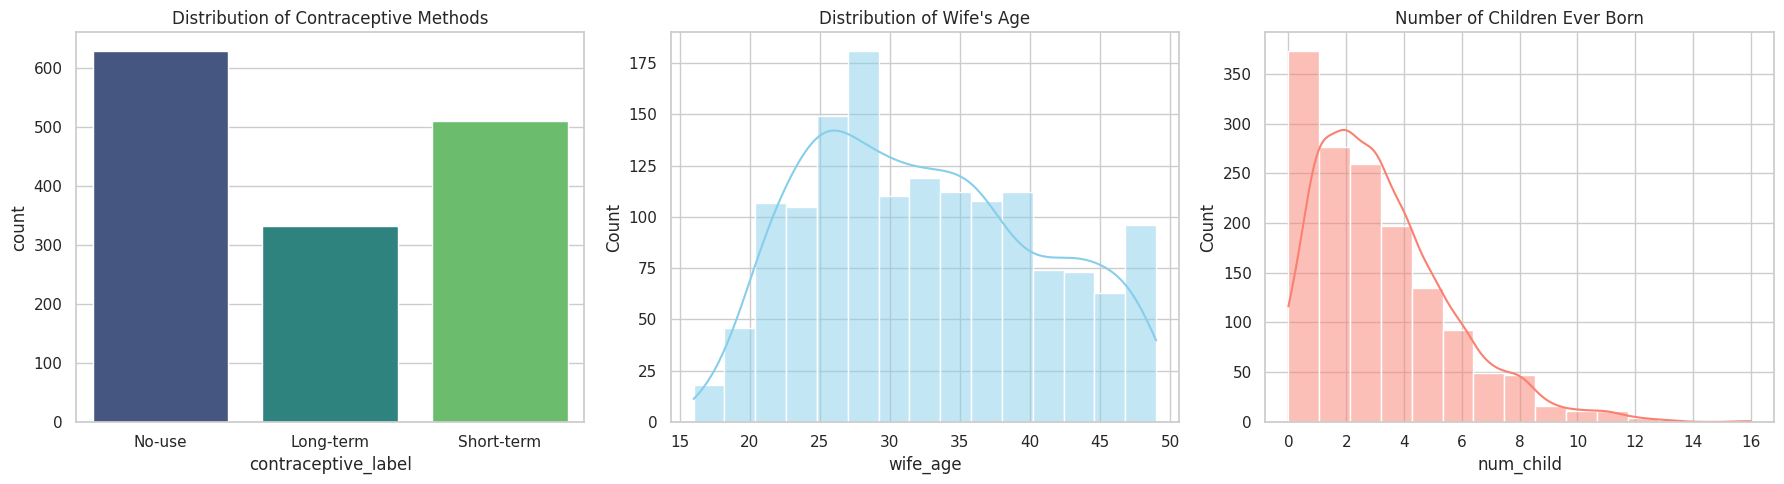

In [5]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Target Distribution
sns.countplot(data=df_labeled, x='contraceptive_label', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Contraceptive Methods')

# Wife's Age Distribution
sns.histplot(df_labeled['wife_age'], bins=15, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Wife\'s Age')

# Number of Children Distribution
sns.histplot(df_labeled['num_child'], bins=15, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Number of Children Ever Born')

plt.tight_layout()
plt.show()

## **Bivariate Analysis: Age and Children vs. Choice**

/tmp/ipykernel_12702/4147003252.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_labeled, x='contraceptive_label', y='wife_age', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_12702/4147003252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_labeled, x='contraceptive_label', y='num_child', ax=axes[1], palette='coolwarm')


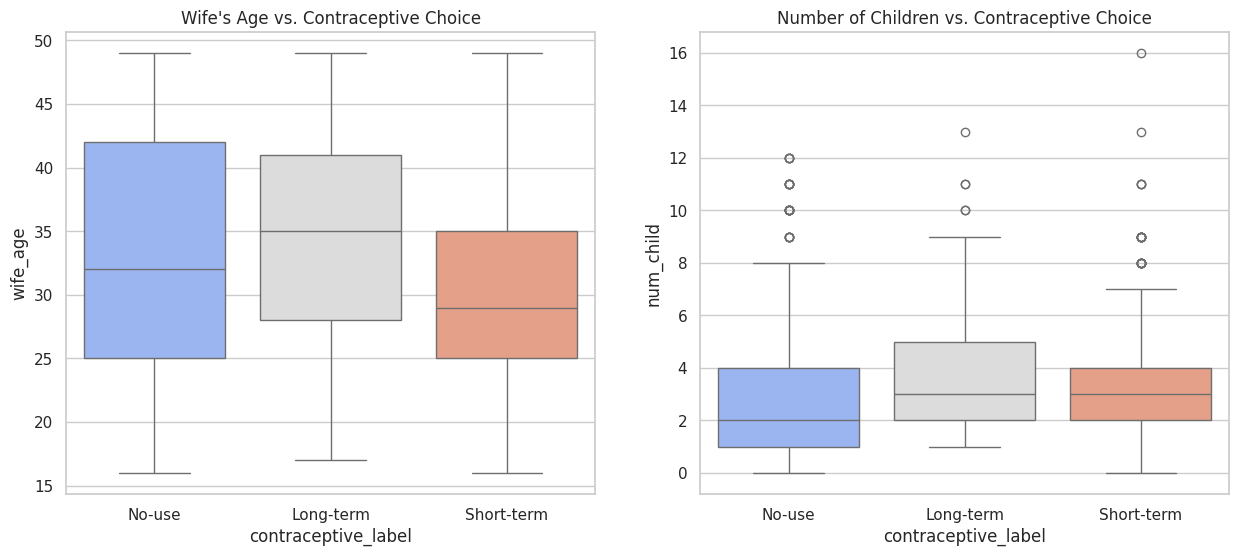

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age vs Choice
sns.boxplot(data=df_labeled, x='contraceptive_label', y='wife_age', ax=axes[0], palette='coolwarm')
axes[0].set_title('Wife\'s Age vs. Contraceptive Choice')

# Children vs Choice
sns.boxplot(data=df_labeled, x='contraceptive_label', y='num_child', ax=axes[1], palette='coolwarm')
axes[1].set_title('Number of Children vs. Contraceptive Choice')

plt.show()

## **Scattter Plot**

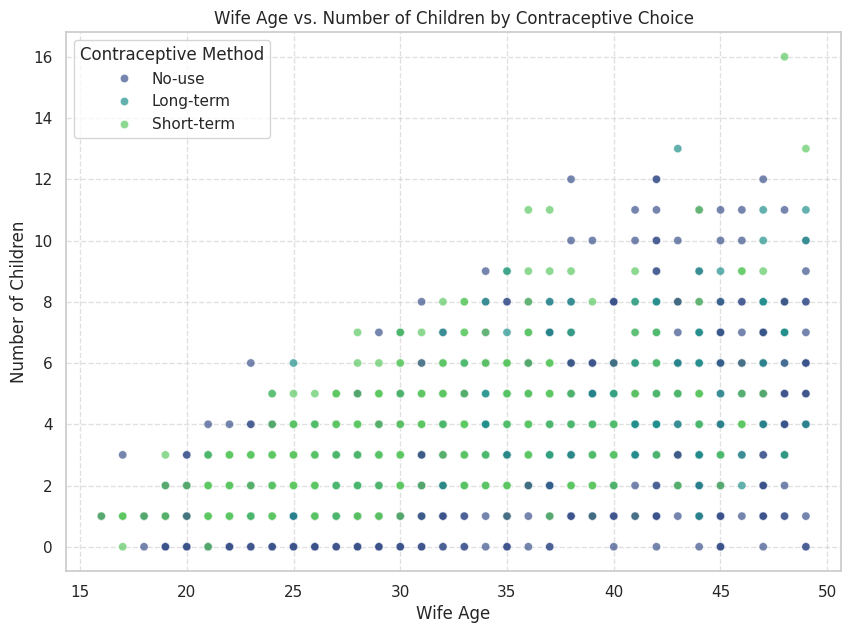

In [7]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_labeled, x='wife_age', y='num_child', hue='contraceptive_label', palette='viridis', alpha=0.7)
plt.title('Wife Age vs. Number of Children by Contraceptive Choice')
plt.xlabel('Wife Age')
plt.ylabel('Number of Children')
plt.legend(title='Contraceptive Method')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Contraceptive Method Choice by Education Level**

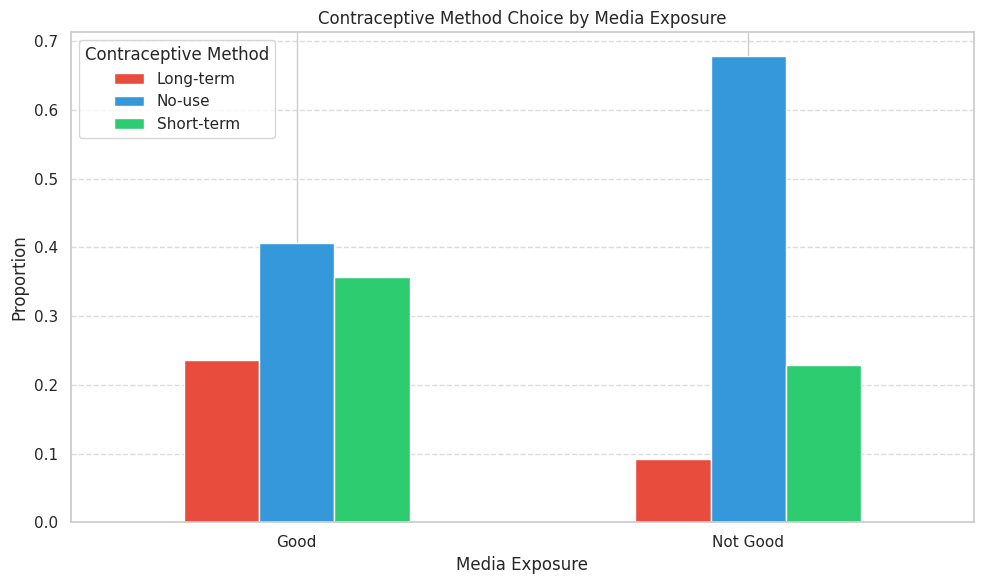

In [8]:
# Create plot_df from df_labeled and map the binary/categorical codes to names
plot_df = df_labeled.copy()

# Mapping Media Exposure (0=Good, 1=Not good)
plot_df['Media'] = plot_df['media_exp'].map({0: 'Good', 1: 'Not Good'})

# Using the label columns we created earlier for the charts
plot_df['Method'] = plot_df['contraceptive_label']
plot_df['Education'] = plot_df['wife_edu_label']

# --- Now your plotting code will work ---

# Recalculate med_ct
med_ct = pd.crosstab(plot_df['Media'], plot_df['Method'], normalize='index')

# Plotting as grouped bar chart
med_ct.plot(kind='bar', figsize=(10, 6), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Contraceptive Method Choice by Media Exposure')
plt.xlabel('Media Exposure')
plt.ylabel('Proportion')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Contraceptive Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Contraceptive Method Choice by Media Exposure**

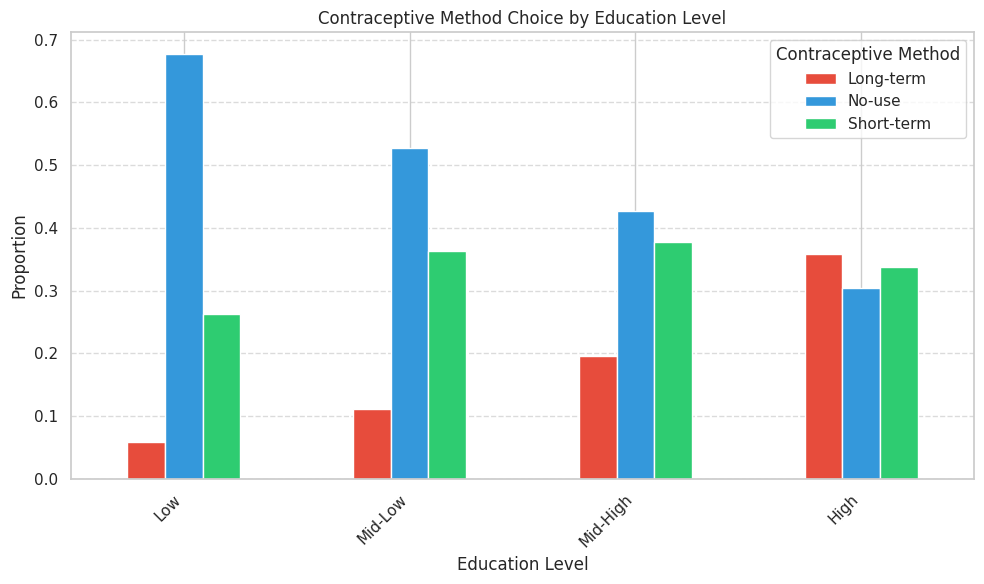

In [9]:
# Recalculate edu_ct to ensure it reflects 'No Use', 'Long-term', 'Short-term'
edu_ct = pd.crosstab(plot_df['Education'], plot_df['Method'], normalize='index')

# Ensure logical ordering from Low to High
edu_order = ['Low', 'Mid-Low', 'Mid-High', 'High']
edu_ct_ordered = edu_ct.reindex(edu_order)

# Plotting as grouped bar chart
edu_ct_ordered.plot(kind='bar', figsize=(10, 6), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Contraceptive Method Choice by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Contraceptive Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Correlation Analysis**

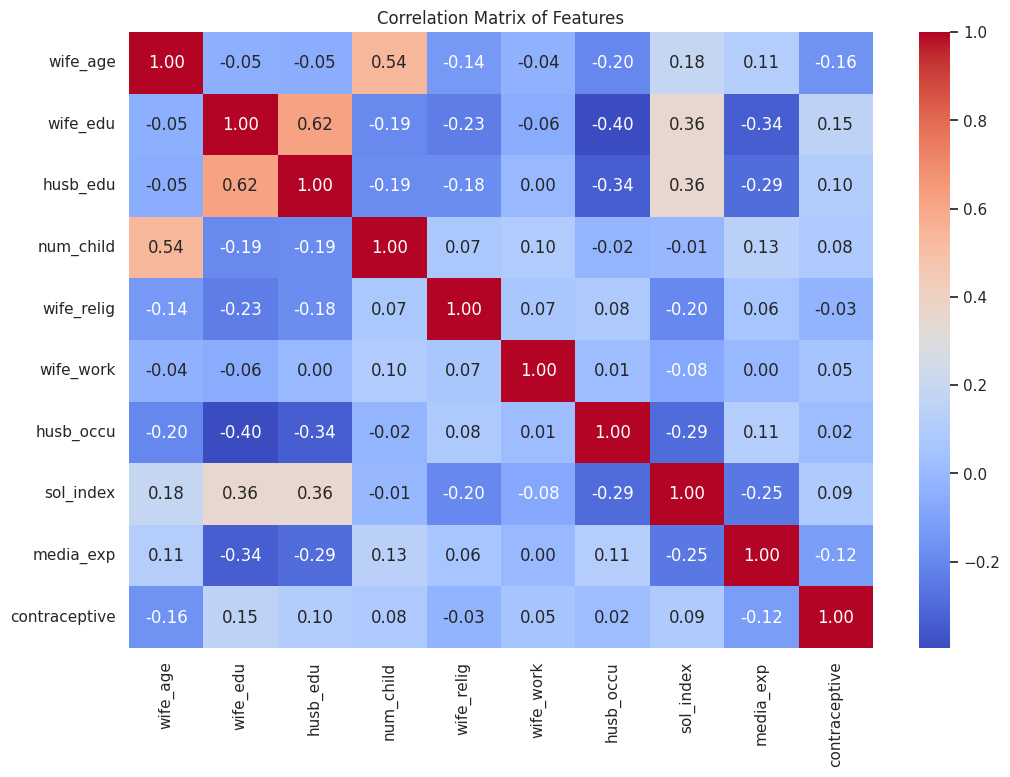

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [11]:
df.head()

,wife_age,wife_edu,husb_edu,num_child,wife_relig,wife_work,husb_occu,sol_index,media_exp,contraceptive
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


# **Preprocessing**

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

# 1. Define Column Groups
# Based on your df.head(): wife_age, wife_edu, husb_edu, num_child, wife_relig, wife_work, husb_occusol_index, media_exp
# Note: Ensure 'husb_occu' and 'sol_index' are split correctly in your dataframe if they merged.
ordinal_cols = ['wife_edu', 'husb_edu', 'sol_index']
categorical_cols = ['wife_relig', 'wife_work', 'husb_occu', 'media_exp']
numerical_cols = ['wife_age', 'num_child']

# 2. Advanced Preprocessing Logic
# - PowerTransformer: Makes numerical data more 'Normal', helping DL models.
# - OneHotEncoder: Handles nominal categories.
# - StandardScaler: Final pass to ensure all features are on the same mean/std.

numeric_transformer = PowerTransformer(method='yeo-johnson')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('ord', StandardScaler(), ordinal_cols) # Scaling ordinals often helps DL models
    ])

# 3. Separate Features and Target
X = df.drop('contraceptive', axis=1)
y = df['contraceptive']

# 4. Split into Training and Test sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Apply the transformation
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Final Global Scaling (Critical for Neural Networks/SVM)
final_scaler = StandardScaler()
X_train_processed = final_scaler.fit_transform(X_train_processed)
X_test_processed = final_scaler.transform(X_test_processed)

print("Preprocessing complete with Advanced Scaling.")
print("Training shape:", X_train_processed.shape)

Preprocessing complete with Advanced Scaling.
Training shape: (1178, 11)


# **Model Training**

## **Training & Evaluation**

In [13]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize models (if not already done)
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

print(f"{'Model':<20} | {'Acc':<6} | {'F1':<6} | {'Prec':<6} | {'Rec':<6} | {'Train(s)':<8} | {'Test(s)':<8}")
print("-" * 85)

for name, model in models.items():
    # --- Training Phase ---
    start_train = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_train

    # --- Testing Phase ---
    start_test = time.time()
    y_pred = model.predict(X_test_processed)
    test_time = time.time() - start_test

    # --- Metrics Calculation ---
    # Using 'weighted' average to account for potential class imbalance
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "Train Time": train_time,
        "Test Time": test_time
    })

    print(f"{name:<20} | {acc:.4f} | {f1:.4f} | {prec:.4f} | {rec:.4f} | {train_time:.4f} | {test_time:.4f}")

# Convert results to a DataFrame for easier analysis/plotting
results_df = pd.DataFrame(results)

Model                | Acc    | F1     | Prec   | Rec    | Train(s) | Test(s) 
-------------------------------------------------------------------------------------
SVM                  | 0.5559 | 0.5525 | 0.5592 | 0.5559 | 1.0928 | 0.0446
Logistic Regression  | 0.5559 | 0.5502 | 0.5553 | 0.5559 | 0.0682 | 0.0005
Random Forest        | 0.5051 | 0.4990 | 0.4965 | 0.5051 | 0.5805 | 0.0242


## **Visualization**

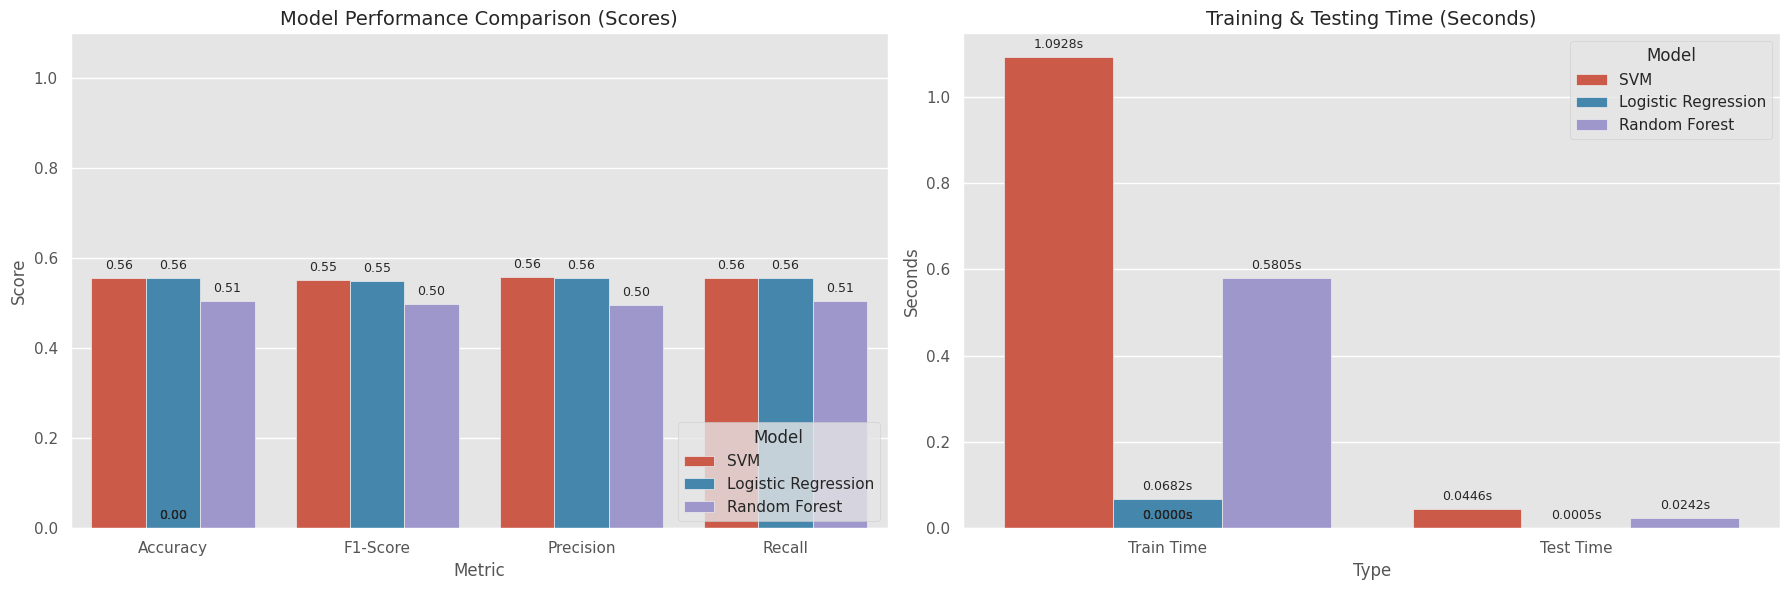

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for plotting
# Reshape the results for performance metrics (0 to 1 scale)
perf_metrics = results_df.melt(id_vars="Model",
                               value_vars=["Accuracy", "F1-Score", "Precision", "Recall"],
                               var_name="Metric", value_name="Score")

# Reshape the results for timing metrics (seconds scale)
time_metrics = results_df.melt(id_vars="Model",
                               value_vars=["Train Time", "Test Time"],
                               var_name="Type", value_name="Seconds")

# 2. Set up the figure
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Performance Comparison
sns.barplot(data=perf_metrics, x="Metric", y="Score", hue="Model", ax=ax[0])
ax[0].set_title("Model Performance Comparison (Scores)", fontsize=14)
ax[0].set_ylim(0, 1.1)  # Set limit slightly above 1 for labels
ax[0].legend(title="Model", loc='lower right')
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

# Plot 2: Efficiency Comparison (Timing)
sns.barplot(data=time_metrics, x="Type", y="Seconds", hue="Model", ax=ax[1])
ax[1].set_title("Training & Testing Time (Seconds)", fontsize=14)
ax[1].legend(title="Model")
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.4f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png')

## **Confusion Matrix**

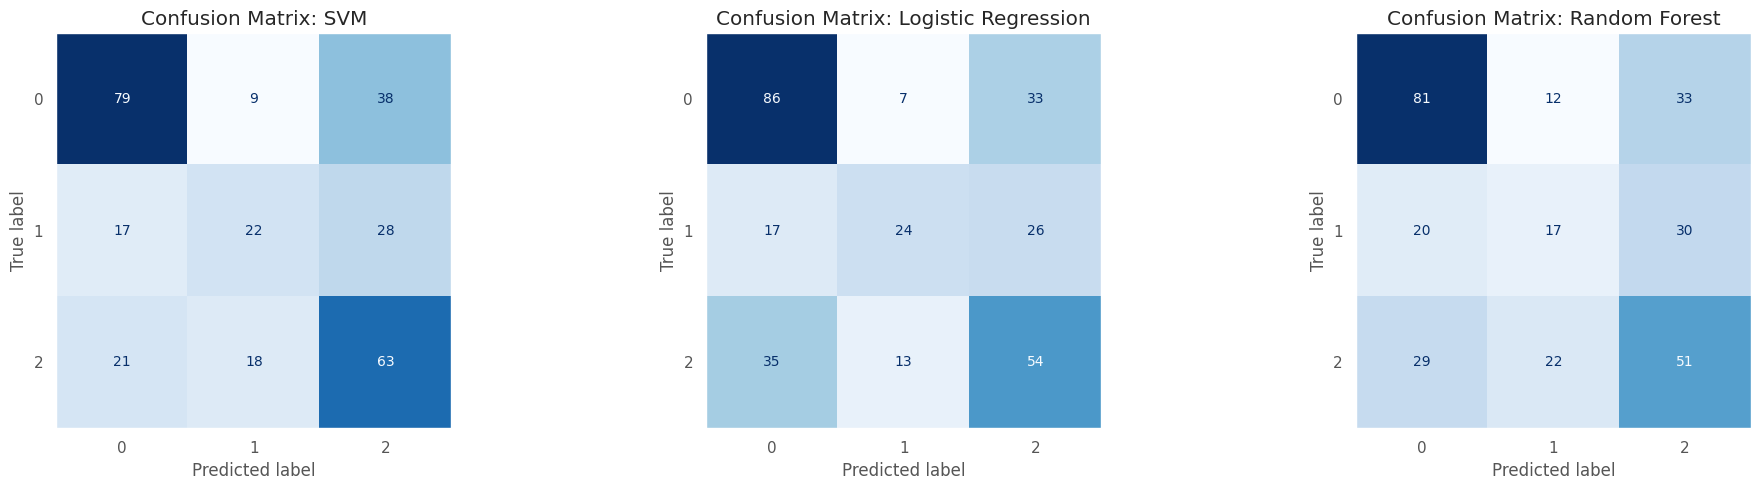

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

## **ROC Curve**

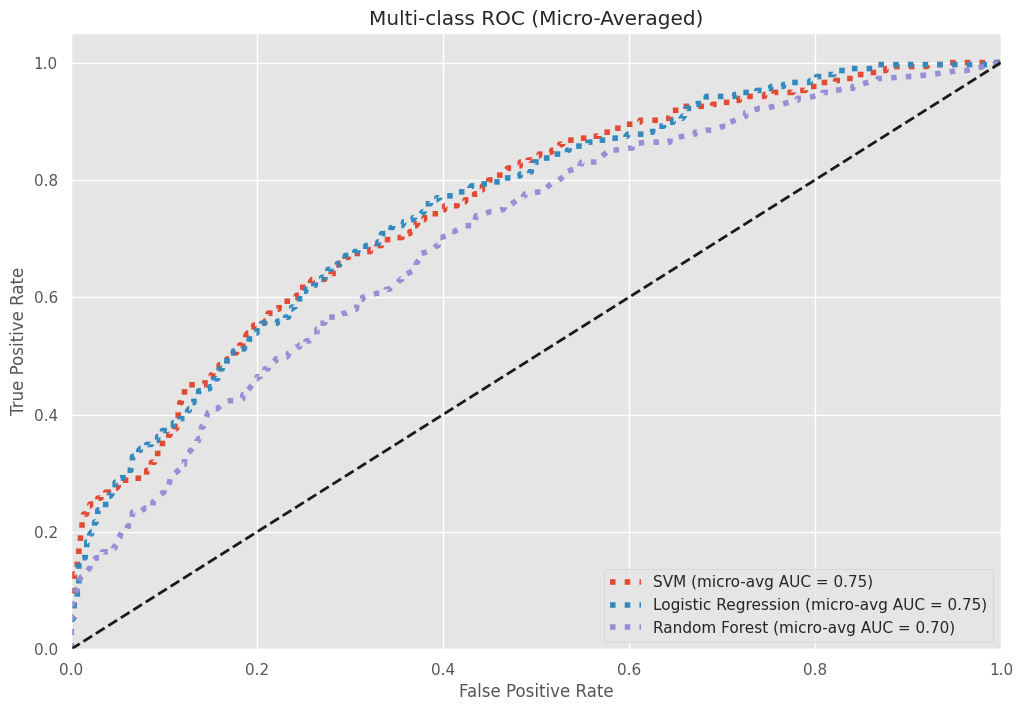

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multi-class ROC
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 8))

colors = ['aqua', 'darkorange', 'cornflowerblue']

for i, (name, model) in enumerate(models.items()):
    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_processed)
    else: # For SVM if probability=False
        y_score = model.decision_function(X_test_processed)

    # Compute ROC curve and ROC area for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])

    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"],
             label=f'{name} (micro-avg AUC = {roc_auc["micro"]:0.2f})',
             linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC (Micro-Averaged)')
plt.legend(loc="lower right")
plt.show()

# **Hyperparameter Tuning**

In [17]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Define Parameter Grids for each model
param_grids = {
    "SVM": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs'],
        'max_iter': [1000]
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
}

tuned_results = []

print(f"{'Model (Tuned)':<20} | {'Acc':<6} | {'F1':<6} | {'Prec':<6} | {'Rec':<6} | {'Train(s)':<8} | {'Test(s)':<8}")
print("-" * 90)

for name, model in models.items():
    # --- Tuning Phase ---
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )
    grid_search.fit(X_train_processed, y_train)

    # Extract the best estimator
    best_model = grid_search.best_estimator_

    # --- Re-measure Final Train Time ---
    start_train = time.time()
    best_model.fit(X_train_processed, y_train)
    train_time = time.time() - start_train

    # --- Re-measure Final Test Time ---
    start_test = time.time()
    y_pred = best_model.predict(X_test_processed)
    test_time = time.time() - start_test

    # --- Final Metrics ---
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    tuned_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "Train Time": train_time,
        "Test Time": test_time
    })

    print(f"{name:<20} | {acc:.4f} | {f1:.4f} | {prec:.4f} | {rec:.4f} | {train_time:.4f} | {test_time:.4f}")

# Optional: View best parameters found
for res in tuned_results:
    print(f"\n[Best {res['Model']}]: {res['Best Params']}")

Model (Tuned)        | Acc    | F1     | Prec   | Rec    | Train(s) | Test(s) 
------------------------------------------------------------------------------------------
SVM                  | 0.5559 | 0.5525 | 0.5592 | 0.5559 | 0.3609 | 0.0185
Logistic Regression  | 0.5559 | 0.5502 | 0.5553 | 0.5559 | 0.0090 | 0.0004
Random Forest        | 0.5525 | 0.5479 | 0.5466 | 0.5525 | 0.4750 | 0.0222

[Best SVM]: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

[Best Logistic Regression]: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}

[Best Random Forest]: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


# **Feature Engineering**

In [18]:
import numpy as np

# 1. Binary Conversion Logic
# Original classes: 1=No use, 2=Long-term, 3=Short-term
# New classes: 0 = No use, 1 = Using (Long or Short term)
def convert_to_binary(target):
    return np.where(target == 1, 0, 1)

y_binary = convert_to_binary(y)

# 2. Feature Engineering
# We will create new features before the split/transformation
X_engineered = X.copy()

# Feature: Socio-economic Impact (Interaction between Education and SOL)
# Higher index suggests more resources/access
X_engineered['edu_sol_impact'] = X_engineered['wife_edu'] * X_engineered['sol_index']

# Feature: Age vs Children ratio
# Can indicate "fertility pressure" or stage of life
X_engineered['child_per_age'] = X_engineered['num_child'] / (X_engineered['wife_age'] + 1)

# 3. Update Column Groups for the Transformer
# Add the new numerical features to your previous list
numerical_cols_eng = numerical_cols + ['edu_sol_impact', 'child_per_age']

# 4. Re-split with Binary Target
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_engineered, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 5. Re-run Preprocessing (using your preprocessor defined earlier)
# Note: You'll need to update 'preprocessor' to include the new numerical columns
from sklearn.compose import ColumnTransformer

preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_eng),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('ord', StandardScaler(), ordinal_cols)
    ])

X_train_proc_bin = preprocessor_eng.fit_transform(X_train_bin)
X_test_proc_bin = preprocessor_eng.transform(X_test_bin)

# Final Scaling
final_scaler_bin = StandardScaler()
X_train_proc_bin = final_scaler_bin.fit_transform(X_train_proc_bin)
X_test_proc_bin = final_scaler_bin.transform(X_test_proc_bin)

print("Binary Conversion and Feature Engineering Complete.")
print(f"New target distribution: {np.bincount(y_binary)}")

Binary Conversion and Feature Engineering Complete.
New target distribution: [629 844]


## **Model Training and Evaluation**

In [19]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Using the binary-processed data from the previous step
# X_train_proc_bin, X_test_proc_bin, y_train_bin, y_test_bin

binary_results = []

print(f"{'Model (Binary)':<20} | {'Acc':<6} | {'F1':<6} | {'Prec':<6} | {'Rec':<6} | {'AUC':<6} | {'Train(s)':<8}")
print("-" * 95)

for name, model in models.items():
    # --- Training ---
    start_train = time.time()
    model.fit(X_train_proc_bin, y_train_bin)
    train_time = time.time() - start_train

    # --- Prediction ---
    start_test = time.time()
    y_pred = model.predict(X_test_proc_bin)
    # Get probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_proc_bin)[:, 1]
    else:
        y_probs = model.decision_function(X_test_proc_bin)
    test_time = time.time() - start_test

    # --- Metrics ---
    acc = accuracy_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred) # Default binary F1
    prec = precision_score(y_test_bin, y_pred)
    rec = recall_score(y_test_bin, y_pred)
    auc_val = roc_auc_score(y_test_bin, y_probs)

    binary_results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "AUC": auc_val,
        "Train Time": train_time,
        "Test Time": test_time
    })

    print(f"{name:<20} | {acc:.4f} | {f1:.4f} | {prec:.4f} | {rec:.4f} | {auc_val:.4f} | {train_time:.4f}")

# Store in DataFrame
df_binary_results = pd.DataFrame(binary_results)

Model (Binary)       | Acc    | F1     | Prec   | Rec    | AUC    | Train(s)
-----------------------------------------------------------------------------------------------
SVM                  | 0.7322 | 0.7959 | 0.7064 | 0.9112 | 0.7745 | 0.2701
Logistic Regression  | 0.7017 | 0.7609 | 0.7035 | 0.8284 | 0.7500 | 0.0097
Random Forest        | 0.6712 | 0.7221 | 0.7000 | 0.7456 | 0.7387 | 0.3162


## **Visualizations**

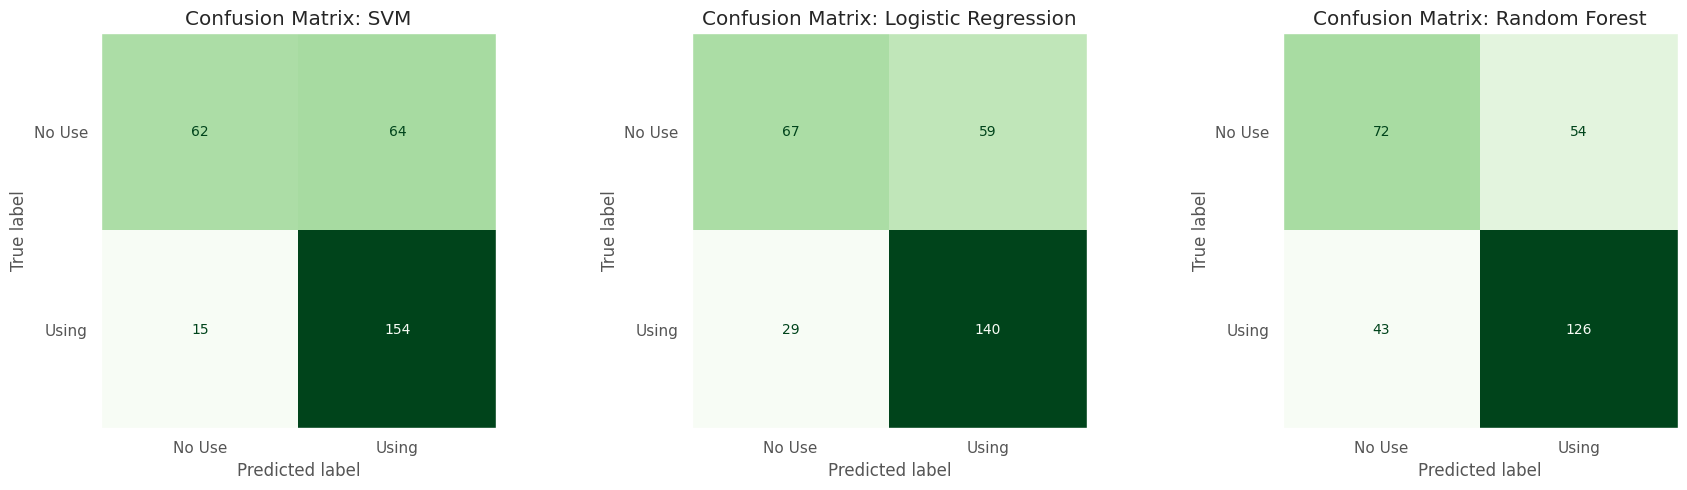

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Set up the figure for the 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# 2. Iterate through models and plot
for i, (name, model) in enumerate(models.items()):
    # Get predictions for the binary target
    y_pred = model.predict(X_test_proc_bin)

    # Generate the matrix
    cm = confusion_matrix(y_test_bin, y_pred)

    # Plotting using ConfusionMatrixDisplay
    # '0' usually represents 'No use', '1' represents 'Using'
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Use', 'Using'])
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)

    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].grid(False) # Clean up grid lines for better visibility

plt.tight_layout()
plt.show()

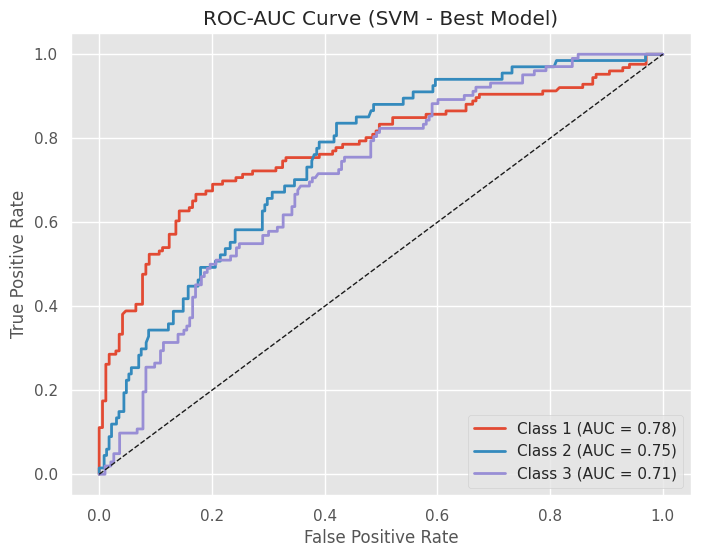

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Train SVM (IMPORTANT: probability=True)
svm = SVC(probability=True, kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

# Get probability scores
y_score = svm.predict_proba(X_test)

# Binarize labels for multiclass ROC
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC curve
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2,
             label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Styling
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (SVM - Best Model)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

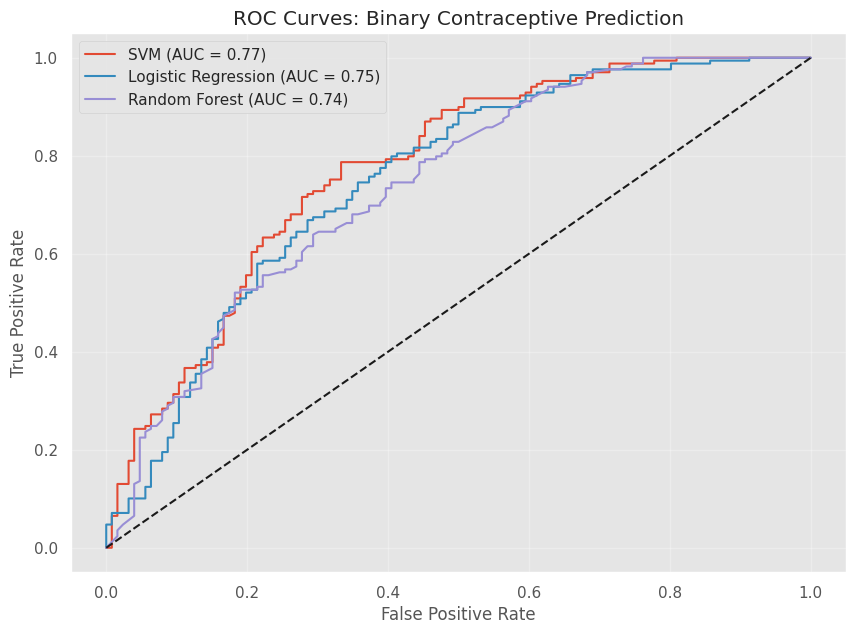

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_proc_bin)[:, 1]
    else:
        y_probs = model.decision_function(X_test_proc_bin)

    fpr, tpr, _ = roc_curve(y_test_bin, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_bin, y_probs):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Binary Contraceptive Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Hyperparameter Tuning After Feature Engineering**

In [22]:
import time
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Define Parameter Grids (Optimized for Binary Case)
param_grids = {
    "SVM": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs'],
        'max_iter': [1000]
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
}

tuned_binary_results = []

print(f"{'Model (Tuned Binary)':<20} | {'Acc':<6} | {'F1':<6} | {'Prec':<6} | {'Rec':<6} | {'AUC':<6} | {'Train(s)':<8}")
print("-" * 105)

for name, model in models.items():
    # --- Grid Search Phase ---
    # We optimize for F1-score to balance Precision and Recall
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid_search.fit(X_train_proc_bin, y_train_bin)

    # Extract the best version of the model
    best_model = grid_search.best_estimator_

    # --- Final Training Time ---
    start_train = time.time()
    best_model.fit(X_train_proc_bin, y_train_bin)
    train_time = time.time() - start_train

    # --- Final Testing & Timing ---
    start_test = time.time()
    y_pred = best_model.predict(X_test_proc_bin)

    if hasattr(best_model, "predict_proba"):
        y_probs = best_model.predict_proba(X_test_proc_bin)[:, 1]
    else:
        y_probs = best_model.decision_function(X_test_proc_bin)
    test_time = time.time() - start_test

    # --- Metrics ---
    acc = accuracy_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred)
    prec = precision_score(y_test_bin, y_pred)
    rec = recall_score(y_test_bin, y_pred)
    auc_val = roc_auc_score(y_test_bin, y_probs)

    tuned_binary_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "AUC": auc_val,
        "Train Time": train_time,
        "Test Time": test_time
    })

    print(f"{name:<20} | {acc:.4f} | {f1:.4f} | {prec:.4f} | {rec:.4f} | {auc_val:.4f} | {train_time:.4f}")

# Convert to DataFrame for final documentation
df_tuned_binary = pd.DataFrame(tuned_binary_results)

Model (Tuned Binary) | Acc    | F1     | Prec   | Rec    | AUC    | Train(s)
---------------------------------------------------------------------------------------------------------
SVM                  | 0.7322 | 0.7959 | 0.7064 | 0.9112 | 0.7745 | 0.2797
Logistic Regression  | 0.7017 | 0.7634 | 0.6995 | 0.8402 | 0.7445 | 0.0081
Random Forest        | 0.7356 | 0.7892 | 0.7264 | 0.8639 | 0.7832 | 0.4692


## **K-Fold Cross Validation**

In [23]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import cross_validate, StratifiedKFold

# 1. Initialize Stratified K-Fold
# Stratified ensures each fold has the same class balance as the whole dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define metrics to calculate
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

kf_detailed_results = []

print(f"{'Model':<20} | {'Metric':<10} | {'Mean':<8} | {'Std Dev':<8}")
print("-" * 55)

for name, model in models.items():
    # Perform Cross Validation
    cv_results = cross_validate(
        model,
        X_train_proc_bin,
        y_train_bin,
        cv=skf,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    # Extract results for each metric
    metrics_summary = {
        "Model": name,
        "Acc_Mean": np.mean(cv_results['test_accuracy']),
        "Acc_Std":  np.std(cv_results['test_accuracy']),
        "F1_Mean":  np.mean(cv_results['test_f1']),
        "F1_Std":   np.std(cv_results['test_f1']),
        "Prec_Mean": np.mean(cv_results['test_precision']),
        "Prec_Std":  np.std(cv_results['test_precision']),
        "Rec_Mean":  np.mean(cv_results['test_recall']),
        "Rec_Std":   np.std(cv_results['test_recall']),
        "Avg_Fit_Time": np.mean(cv_results['fit_time'])
    }

    kf_detailed_results.append(metrics_summary)

    # Print a quick summary for F1 and Accuracy
    print(f"{name:<20} | F1-Score   | {metrics_summary['F1_Mean']:.4f} | {metrics_summary['F1_Std']:.4f}")
    print(f"{'':<20} | Accuracy   | {metrics_summary['Acc_Mean']:.4f} | {metrics_summary['Acc_Std']:.4f}")
    print("-" * 55)

# Convert to a formatted DataFrame for better viewing
df_kf_final = pd.DataFrame(kf_detailed_results)

Model                | Metric     | Mean     | Std Dev 
-------------------------------------------------------
SVM                  | F1-Score   | 0.7768 | 0.0222
                     | Accuracy   | 0.7063 | 0.0297
-------------------------------------------------------
Logistic Regression  | F1-Score   | 0.7551 | 0.0187
                     | Accuracy   | 0.6944 | 0.0250
-------------------------------------------------------
Random Forest        | F1-Score   | 0.7232 | 0.0148
                     | Accuracy   | 0.6706 | 0.0182
-------------------------------------------------------
